In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

df = pd.read_csv('../results/records.csv', index_col=0)
df['group'] = df.index.str.split('/').str[0]
df['short'] = df.index.str.split('/').str[1]

# Nomi brevi per i modelli FM
FM_NT = 'NTv3'
FM_HY = 'HyenaDNA'

# Palette per gruppi
groups = sorted(df['group'].unique())
cmap = plt.colormaps['tab20']
GROUP_COLORS = {g: cmap(i) for i, g in enumerate(groups)}

print(f'{len(df)} dataset, {len(groups)} gruppi: {", ".join(groups)}')
print(f'Colonne: {len(df.columns)}')
df[['n_train','n_test','n_classes','seq_len_mean','gc_content_mean']].describe().round(1)

57 dataset, 12 gruppi: EMP, deep4mc, enhancers, genomic_benchmark, iDHS-EL, iDNA_ABF, iPro-WAEL, mouse, prom, splice, tf, virus
Colonne: 68


,n_train,n_test,n_classes,seq_len_mean,gc_content_mean
count,57.0,57.0,57.0,57.0,57.0
mean,32989.5,12521.9,2.2,323.8,0.5
std,38487.1,14407.3,1.0,326.7,0.1
min,711.0,306.0,2.0,40.0,0.4
25%,10475.0,2982.0,2.0,101.0,0.4
50%,20843.0,8789.0,2.0,251.0,0.5
75%,37146.0,15920.0,2.0,500.0,0.5
max,156697.0,67157.0,9.0,1622.9,0.7


In [13]:
# --- Helper: costruisci DataFrame lungo con tutti i metodi e MCC ---
method_cols = {}
for k in [4,5,6,7,8]:
    c = f'kmer_k{k}_MCC'
    if c in df.columns:
        method_cols[f'k-mer k={k}'] = c

method_cols[f'FM {FM_NT}'] = 'fm_NTv3_650M_pre_MCC'
method_cols[f'FM {FM_HY}'] = 'fm_hyenadna-medium-160k-seqlen-hf_MCC'

for fm, tag in [(FM_NT, 'NTv3_650M_pre'), (FM_HY, 'hyenadna-medium-160k-seqlen-hf')]:
    c = f'tok_{tag}_MCC'
    if c in df.columns:
        method_cols[f'Tok {fm}'] = c

long = []
for mname, col in method_cols.items():
    if col in df.columns:
        tmp = df[[col, 'group', 'short']].copy()
        tmp.columns = ['MCC', 'group', 'short']
        tmp['method'] = mname
        long.append(tmp.dropna(subset=['MCC']))

long_df = pd.concat(long, ignore_index=True)
print(f'{len(long_df)} osservazioni (dataset × metodo)')

259 osservazioni (dataset × metodo)


## 1. Completezza dati per metodo e dataset

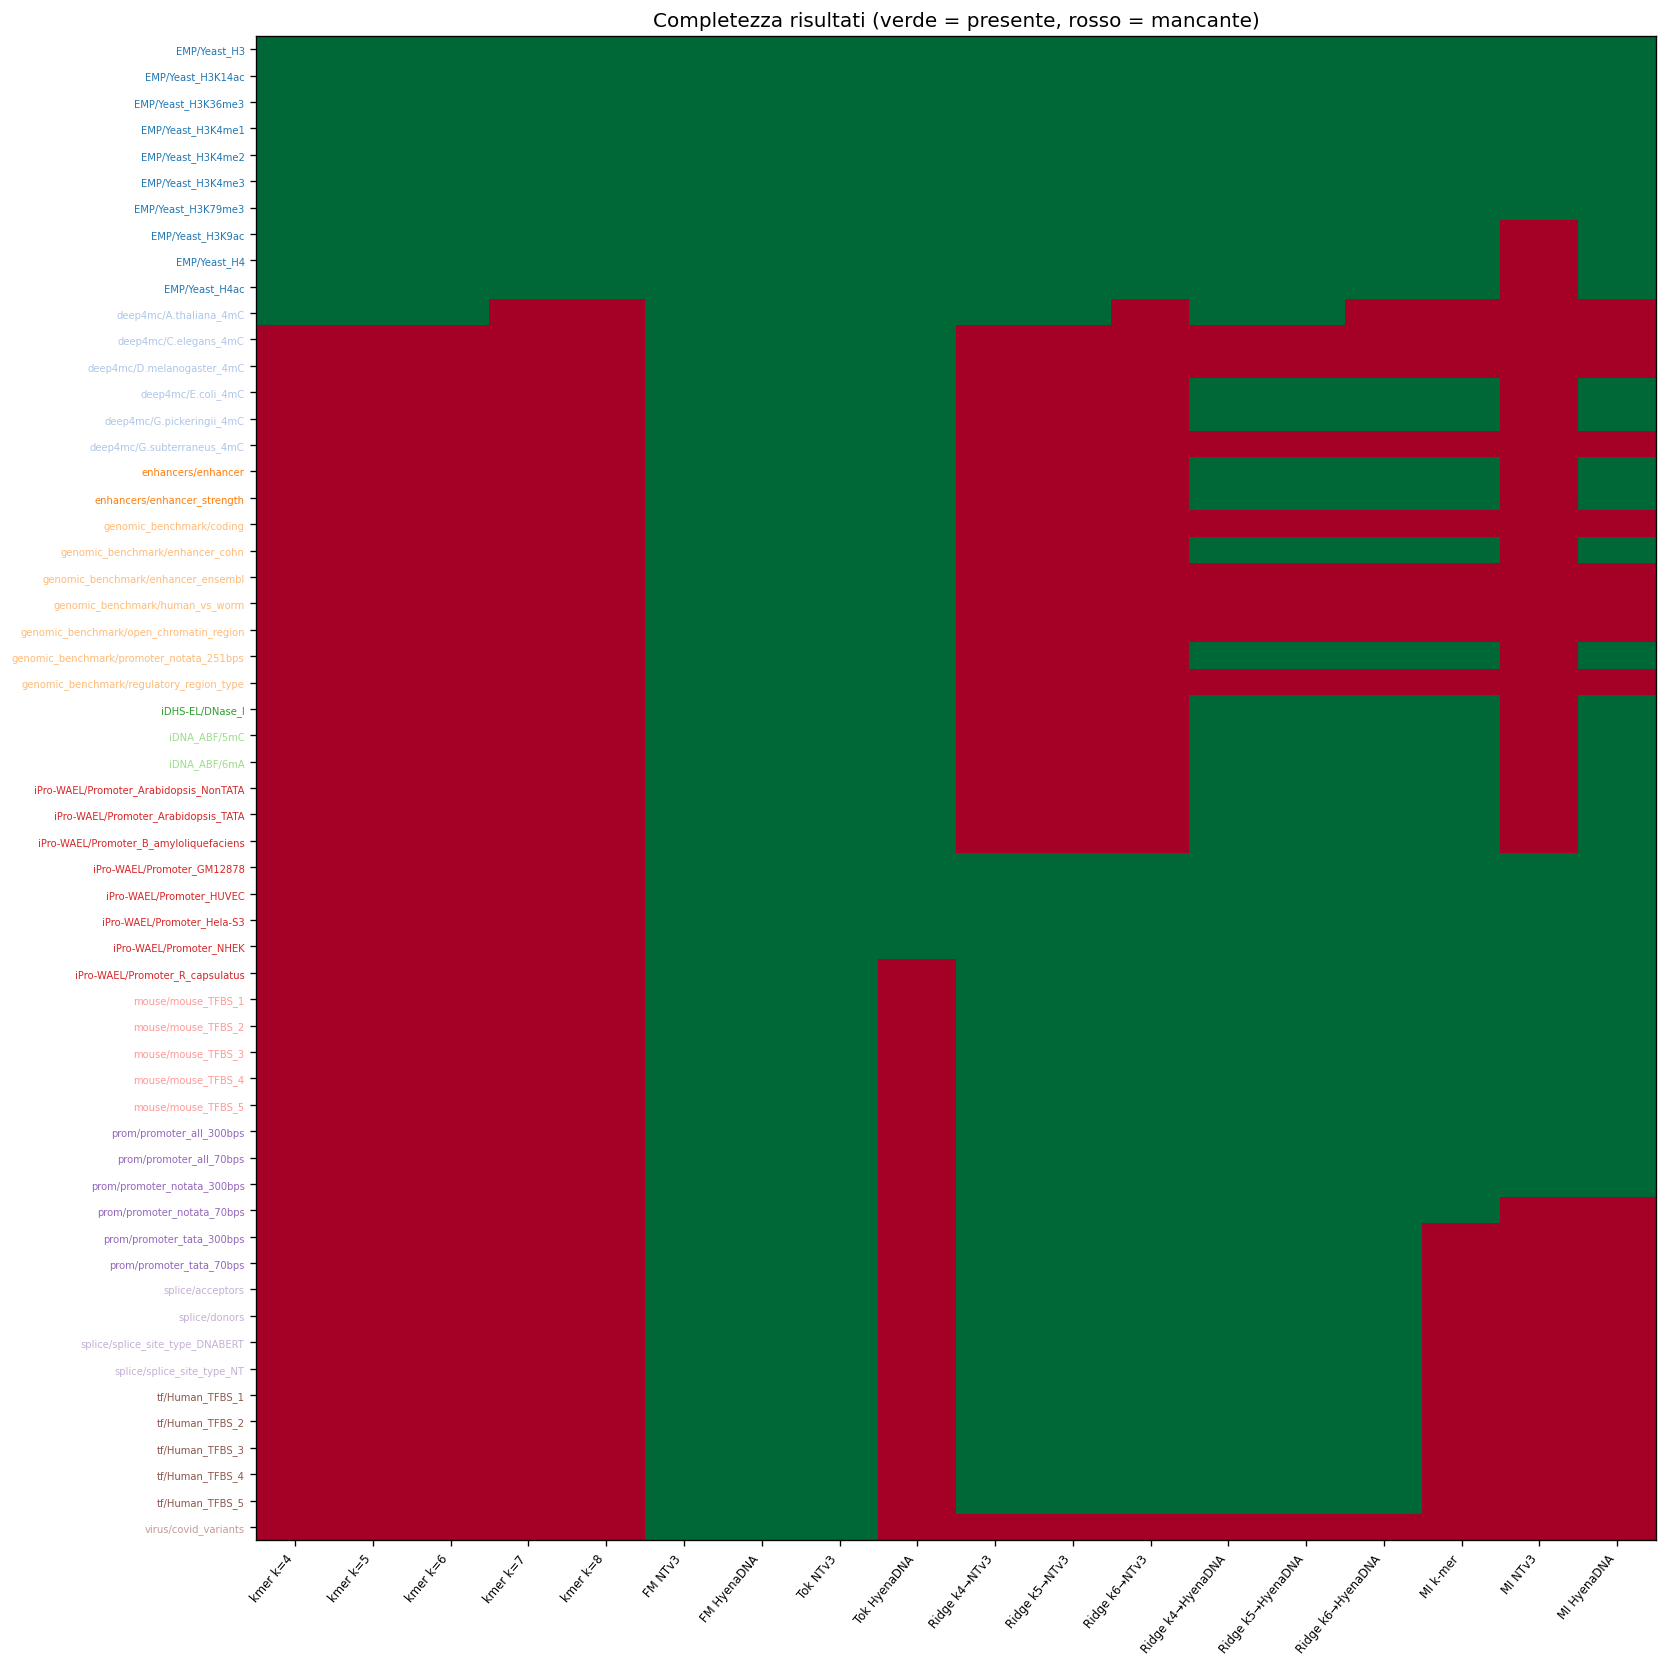

Completezza media: 58%


In [14]:
# Heatmap completezza: proxy columns (una per metodo)
proxy = {}
for k in [4,5,6,7,8]:
    proxy[f'kmer k={k}'] = f'kmer_k{k}_MCC'
proxy[f'FM {FM_NT}'] = 'fm_NTv3_650M_pre_MCC'
proxy[f'FM {FM_HY}'] = 'fm_hyenadna-medium-160k-seqlen-hf_MCC'
for fm, tag in [(FM_NT, 'NTv3_650M_pre'), (FM_HY, 'hyenadna-medium-160k-seqlen-hf')]:
    proxy[f'Tok {fm}'] = f'tok_{tag}_MCC'
for fm, tag in [(FM_NT, 'NTv3_650M_pre'), (FM_HY, 'hyenadna-medium-160k-seqlen-hf')]:
    for k in [4,5,6]:
        c = f'ridge_k{k}_{tag}_R2'
        if c in df.columns:
            proxy[f'Ridge k{k}→{fm}'] = c
proxy['MI k-mer'] = 'mi_kmer_k4'
proxy[f'MI {FM_NT}'] = 'mi_fm_NTv3_650M_pre'
proxy[f'MI {FM_HY}'] = 'mi_fm_hyenadna-medium-160k-seqlen-hf'

valid_proxy = {k: v for k, v in proxy.items() if v in df.columns}
presence = df[[v for v in valid_proxy.values()]].notna().astype(int)
presence.columns = list(valid_proxy.keys())

fig, ax = plt.subplots(figsize=(14, 14))
im = ax.imshow(presence.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(presence.columns)))
ax.set_xticklabels(presence.columns, rotation=50, ha='right', fontsize=7)
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df.index, fontsize=6)
for i, row in enumerate(df.itertuples()):
    ax.get_yticklabels()[i].set_color(GROUP_COLORS[row.group])
ax.set_title('Completezza risultati (verde = presente, rosso = mancante)')
plt.tight_layout()
plt.show()
print(f'Completezza media: {presence.mean().mean():.0%}')

## 2. Distribuzione MCC per metodo (boxplot)

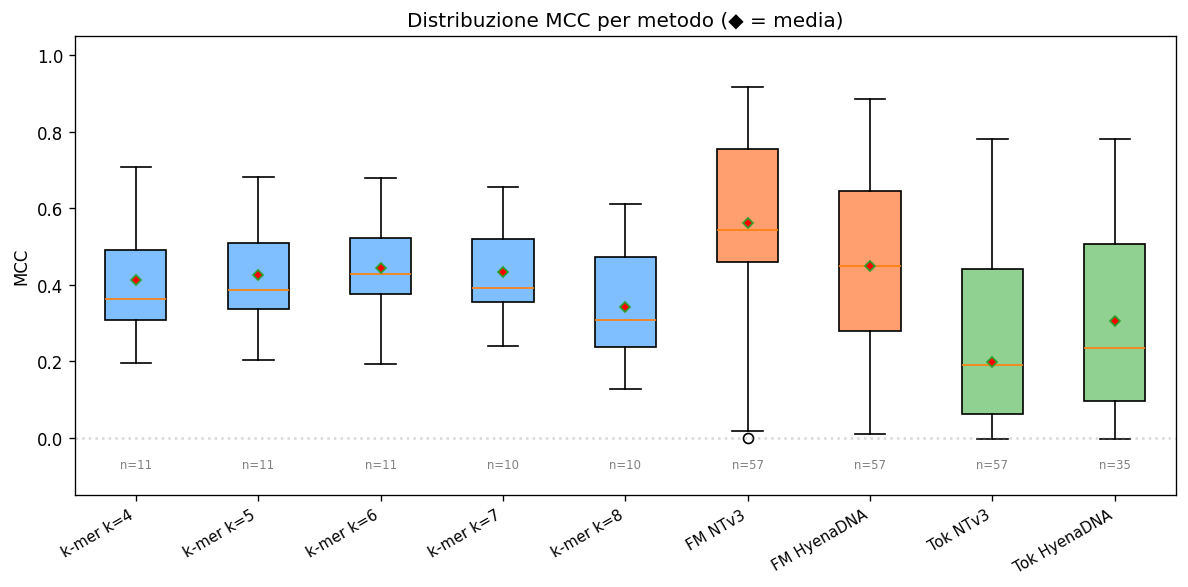

In [15]:
# Boxplot MCC: k-mer, FM embedding, tokenizer
order = [f'k-mer k={k}' for k in [4,5,6,7,8]] + \
        [f'FM {FM_NT}', f'FM {FM_HY}', f'Tok {FM_NT}', f'Tok {FM_HY}']
order = [m for m in order if m in long_df['method'].unique()]

data_box = [long_df.loc[long_df['method']==m, 'MCC'].values for m in order]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(data_box, widths=0.5, patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=4))

# Colori: blu k-mer, arancio FM, verde tokenizer
color_map = {}
for m in order:
    if m.startswith('k-mer'):
        color_map[m] = '#7fbfff'
    elif m.startswith('FM'):
        color_map[m] = '#ff9f6f'
    else:
        color_map[m] = '#90d090'

for patch, m in zip(bp['boxes'], order):
    patch.set_facecolor(color_map[m])

ax.set_xticklabels(order, rotation=30, ha='right', fontsize=9)
for i, vals in enumerate(data_box):
    ax.text(i+1, -0.08, f'n={len(vals)}', ha='center', fontsize=7, color='gray')

ax.set_ylabel('MCC')
ax.set_title('Distribuzione MCC per metodo (◆ = media)')
ax.axhline(0, color='gray', ls=':', alpha=0.3)
ax.set_ylim(-0.15, 1.05)
plt.tight_layout()
plt.show()

## 3. NTv3 vs HyenaDNA: confronto diretto (FM embedding RF)

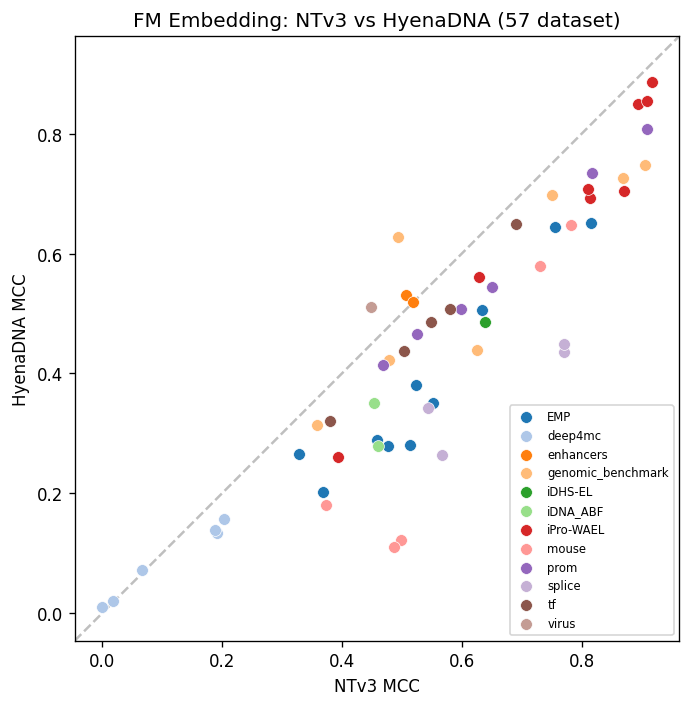

NTv3 vince 50/57, HyenaDNA vince 7/57


In [16]:
col_nt = 'fm_NTv3_650M_pre_MCC'
col_hy = 'fm_hyenadna-medium-160k-seqlen-hf_MCC'
both = df[[col_nt, col_hy, 'group', 'short']].dropna()

fig, ax = plt.subplots(figsize=(6, 6))
for g in groups:
    m = both['group'] == g
    if m.any():
        ax.scatter(both.loc[m, col_nt], both.loc[m, col_hy],
                   c=[GROUP_COLORS[g]], label=g, s=50, edgecolors='white', lw=0.4, zorder=3)

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, '--', color='gray', alpha=0.5, zorder=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(f'{FM_NT} MCC')
ax.set_ylabel(f'{FM_HY} MCC')
ax.set_title(f'FM Embedding: {FM_NT} vs {FM_HY} ({len(both)} dataset)')
ax.legend(fontsize=7, loc='lower right')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

wins_nt = (both[col_nt] > both[col_hy]).sum()
wins_hy = (both[col_hy] > both[col_nt]).sum()
print(f'{FM_NT} vince {wins_nt}/{len(both)}, {FM_HY} vince {wins_hy}/{len(both)}')

## 4. Best k-mer vs Best FM (classificazione RF)

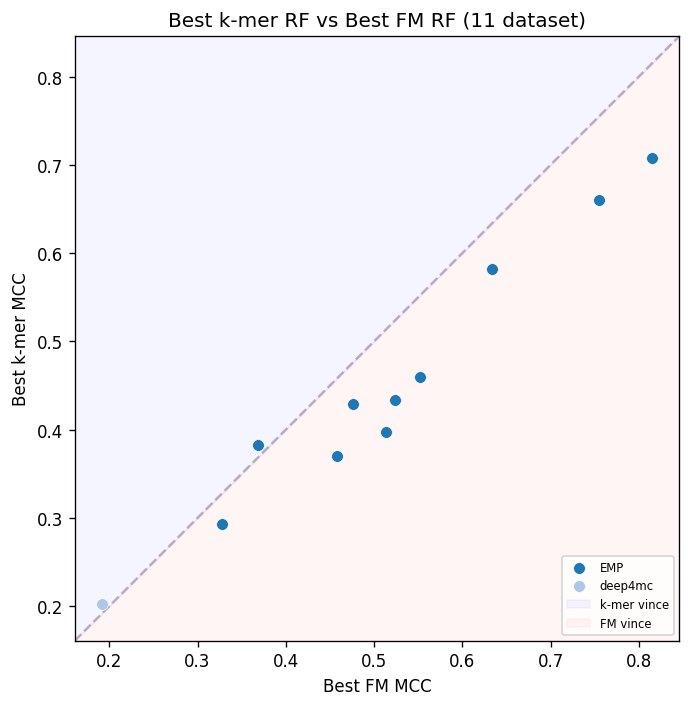

K-mer vince 2/11, FM vince 9/11


In [17]:
kmer_mcc = [f'kmer_k{k}_MCC' for k in [4,5,6,7,8]]
fm_mcc = ['fm_NTv3_650M_pre_MCC', 'fm_hyenadna-medium-160k-seqlen-hf_MCC']

comp = pd.DataFrame({
    'best_kmer': df[kmer_mcc].max(axis=1),
    'best_fm': df[fm_mcc].max(axis=1),
    'group': df['group'], 'short': df['short']
}).dropna()

fig, ax = plt.subplots(figsize=(6, 6))
for g in groups:
    m = comp['group'] == g
    if m.any():
        ax.scatter(comp.loc[m, 'best_fm'], comp.loc[m, 'best_kmer'],
                   c=[GROUP_COLORS[g]], label=g, s=50, edgecolors='white', lw=0.4, zorder=3)

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, '--', color='gray', alpha=0.5, zorder=1)
ax.fill_between(lims, lims, [lims[1]]*2, alpha=0.04, color='blue', label='k-mer vince')
ax.fill_between(lims, [lims[0]]*2, lims, alpha=0.04, color='red', label='FM vince')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Best FM MCC')
ax.set_ylabel('Best k-mer MCC')
ax.set_title(f'Best k-mer RF vs Best FM RF ({len(comp)} dataset)')
ax.legend(fontsize=7, loc='lower right')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

w_k = (comp['best_kmer'] > comp['best_fm']).sum()
w_f = (comp['best_fm'] > comp['best_kmer']).sum()
print(f'K-mer vince {w_k}/{len(comp)}, FM vince {w_f}/{len(comp)}')

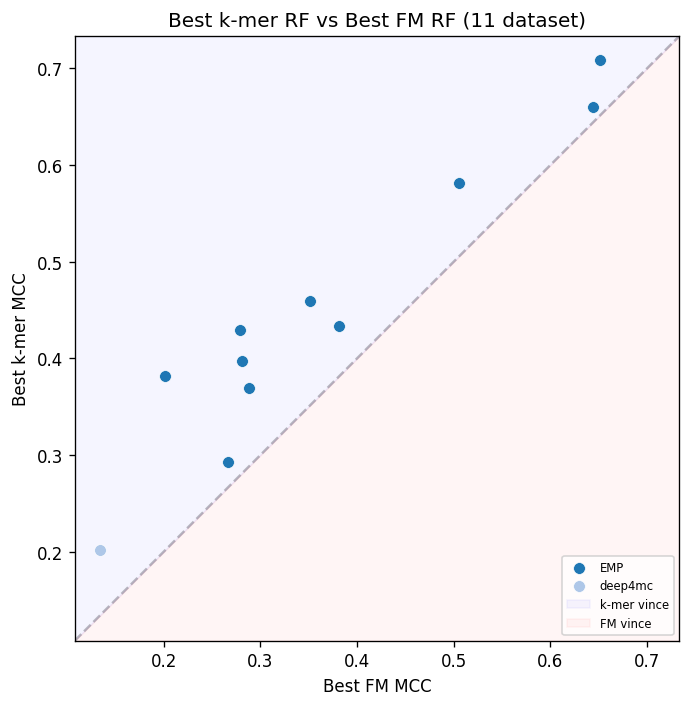

K-mer vince 11/11, FM vince 0/11


In [24]:
kmer_mcc = [f'kmer_k{k}_MCC' for k in [4,5,6,7,8]]
fm_mcc = ['fm_hyenadna-medium-160k-seqlen-hf_MCC']

comp = pd.DataFrame({
    'best_kmer': df[kmer_mcc].max(axis=1),
    'best_fm': df[fm_mcc].max(axis=1),
    'group': df['group'], 'short': df['short']
}).dropna()

fig, ax = plt.subplots(figsize=(6, 6))
for g in groups:
    m = comp['group'] == g
    if m.any():
        ax.scatter(comp.loc[m, 'best_fm'], comp.loc[m, 'best_kmer'],
                   c=[GROUP_COLORS[g]], label=g, s=50, edgecolors='white', lw=0.4, zorder=3)

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, '--', color='gray', alpha=0.5, zorder=1)
ax.fill_between(lims, lims, [lims[1]]*2, alpha=0.04, color='blue', label='k-mer vince')
ax.fill_between(lims, [lims[0]]*2, lims, alpha=0.04, color='red', label='FM vince')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Best FM MCC')
ax.set_ylabel('Best k-mer MCC')
ax.set_title(f'Best k-mer RF vs Best FM RF ({len(comp)} dataset)')
ax.legend(fontsize=7, loc='lower right')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

w_k = (comp['best_kmer'] > comp['best_fm']).sum()
w_f = (comp['best_fm'] > comp['best_kmer']).sum()
print(f'K-mer vince {w_k}/{len(comp)}, FM vince {w_f}/{len(comp)}')

## 5. FM Embedding vs Tokenizer: quanto perde il tokenizer?

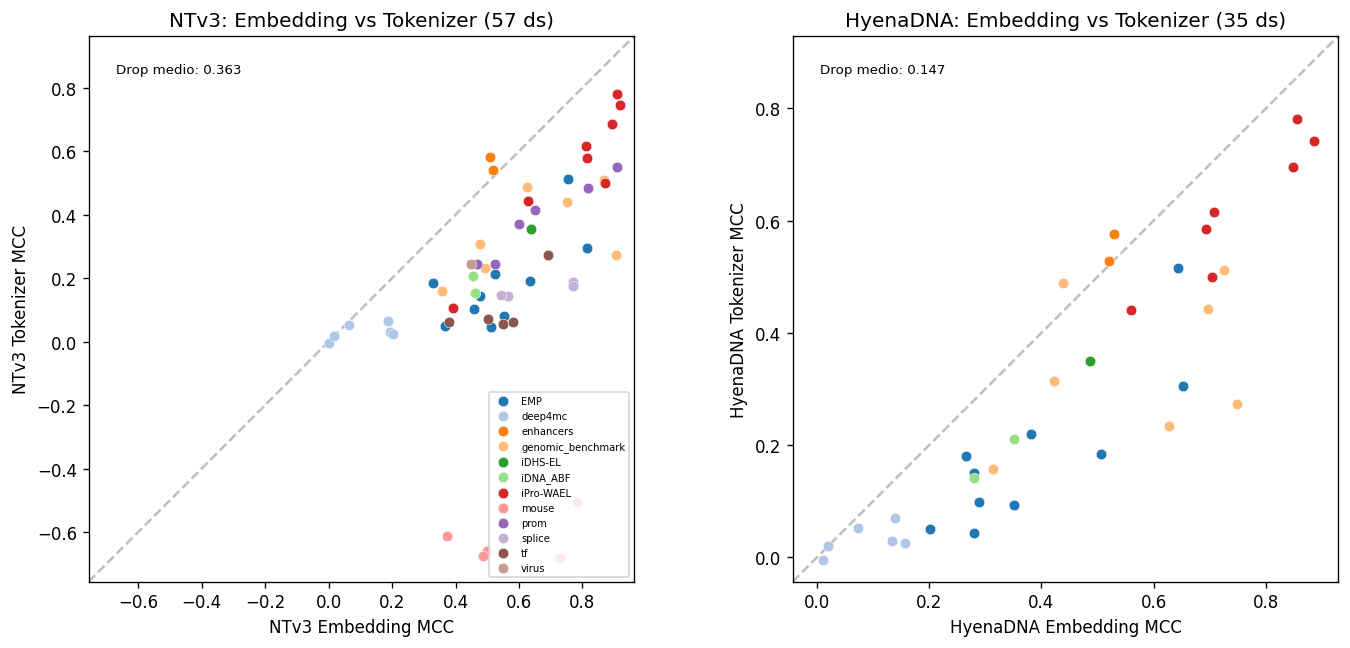

In [18]:
# Scatter: FM embedding MCC vs Tokenizer MCC, per entrambi i modelli
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, (fm, tag) in zip(axes, [(FM_NT, 'NTv3_650M_pre'), (FM_HY, 'hyenadna-medium-160k-seqlen-hf')]):
    emb_col = f'fm_{tag}_MCC'
    tok_col = f'tok_{tag}_MCC'
    sub = df[[emb_col, tok_col, 'group', 'short']].dropna()
    
    for g in groups:
        m = sub['group'] == g
        if m.any():
            ax.scatter(sub.loc[m, emb_col], sub.loc[m, tok_col],
                       c=[GROUP_COLORS[g]], label=g, s=40, edgecolors='white', lw=0.3, zorder=3)
    
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, '--', color='gray', alpha=0.5, zorder=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f'{fm} Embedding MCC')
    ax.set_ylabel(f'{fm} Tokenizer MCC')
    ax.set_title(f'{fm}: Embedding vs Tokenizer ({len(sub)} ds)')
    ax.set_aspect('equal')
    
    drop = (sub[emb_col] - sub[tok_col]).mean()
    ax.text(0.05, 0.95, f'Drop medio: {drop:.3f}', transform=ax.transAxes, fontsize=8, va='top')

axes[0].legend(fontsize=6, loc='lower right')
plt.tight_layout()
plt.show()

## 6. Ridge R²: quanto bene i k-mer approssimano gli embeddings FM?

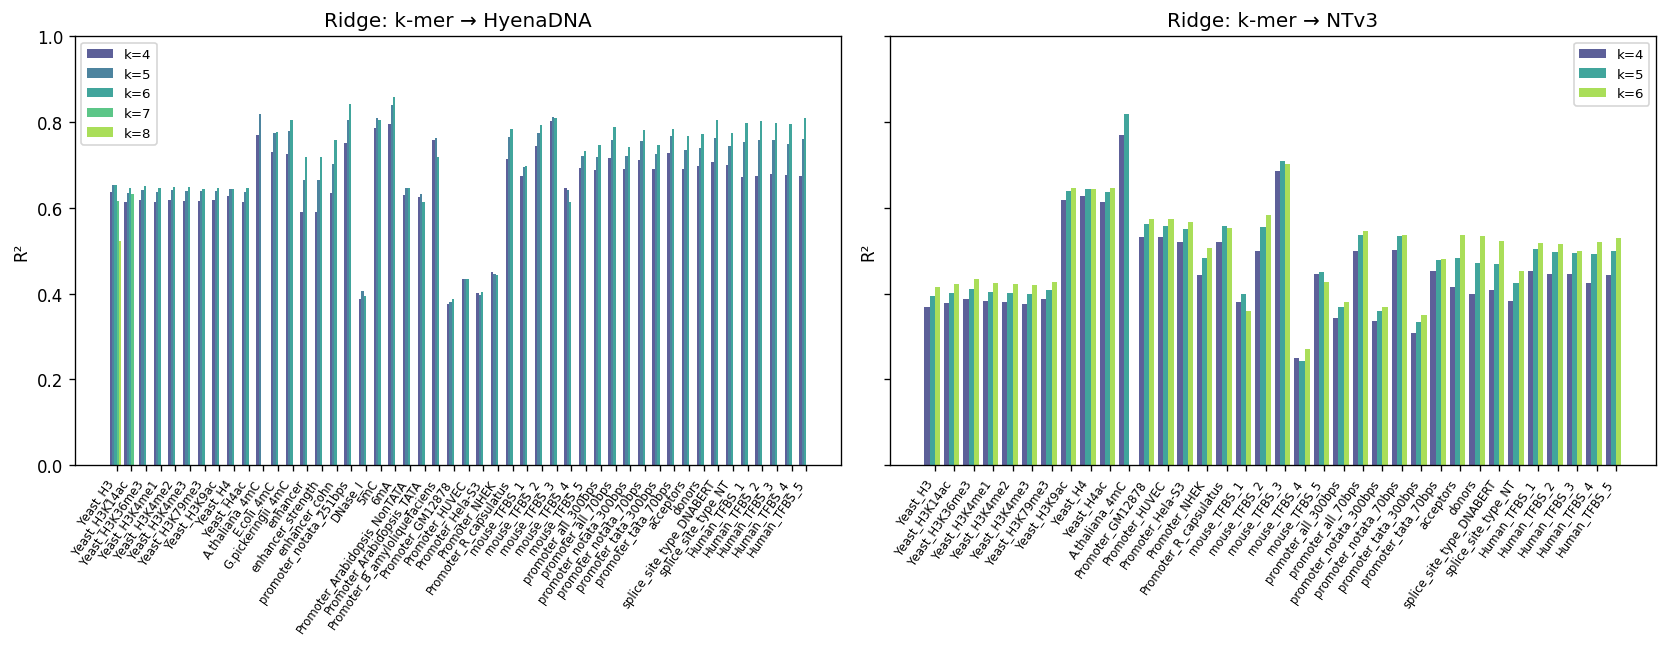

In [19]:
# Ridge R² grouped bar: HyenaDNA (pannello sx) e NTv3 (pannello dx)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax, (fm, tag) in zip(axes, [(FM_HY, 'hyenadna-medium-160k-seqlen-hf'), (FM_NT, 'NTv3_650M_pre')]):
    k_avail = []
    for k in [4,5,6,7,8]:
        c = f'ridge_k{k}_{tag}_R2'
        if c in df.columns:
            k_avail.append(k)
    
    r2_cols = [f'ridge_k{k}_{tag}_R2' for k in k_avail]
    sub = df[r2_cols + ['short']].dropna(subset=[r2_cols[0]])
    
    if len(sub) == 0:
        ax.set_title(f'Ridge → {fm}: nessun dato')
        continue
    
    x = np.arange(len(sub))
    width = 0.8 / len(k_avail)
    colors = plt.colormaps['viridis'](np.linspace(0.2, 0.85, len(k_avail)))
    
    for i, k in enumerate(k_avail):
        col = f'ridge_k{k}_{tag}_R2'
        vals = sub[col].values
        mask = pd.notna(vals)
        ax.bar(x[mask] + i*width, vals[mask].astype(float), width, label=f'k={k}', color=colors[i], alpha=0.85)
    
    ax.set_xticks(x + width * len(k_avail)/2)
    ax.set_xticklabels(sub['short'], rotation=55, ha='right', fontsize=7)
    ax.set_ylabel('R²')
    ax.set_title(f'Ridge: k-mer → {fm}')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 7. Mutual Information: k-mer vs FM

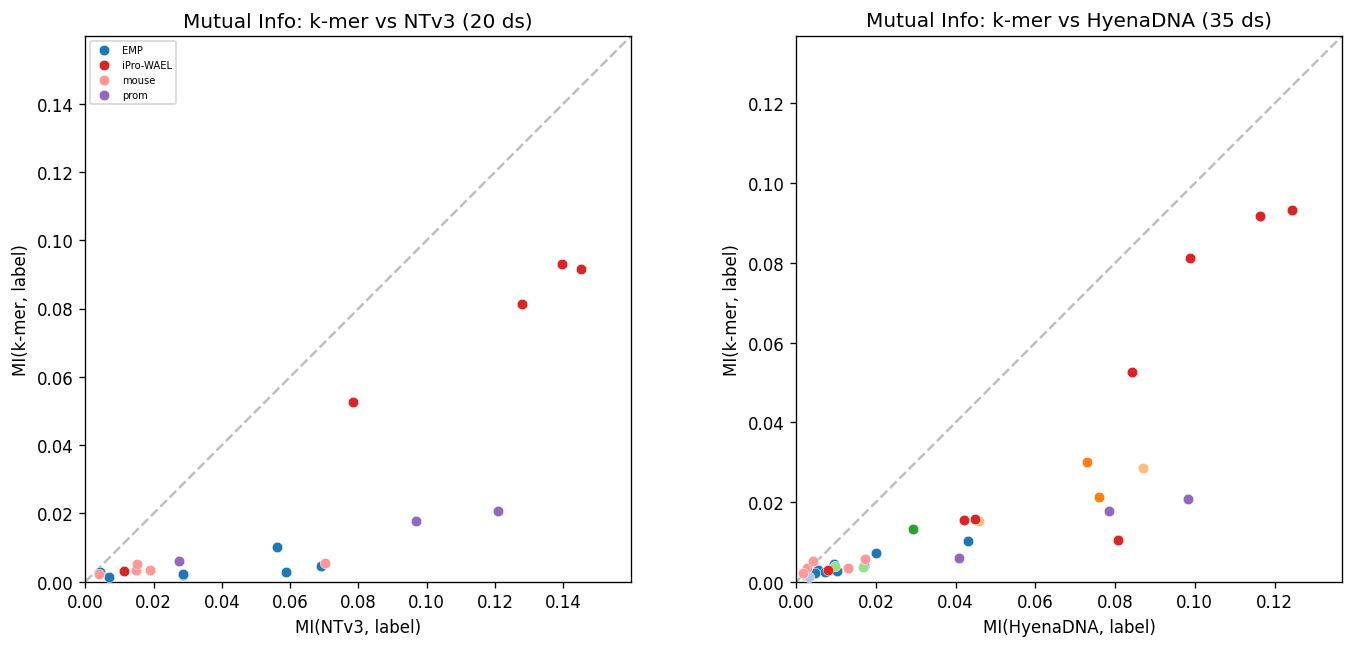

In [20]:
# MI: k-mer (best across k) vs FM per modello
mi_kmer_cols = [c for c in df.columns if c.startswith('mi_kmer_')]
mi_fm_cols = [c for c in df.columns if c.startswith('mi_fm_')]

mi = pd.DataFrame({
    'MI k-mer (best k)': df[mi_kmer_cols].max(axis=1),
    f'MI {FM_NT}': df.get('mi_fm_NTv3_650M_pre'),
    f'MI {FM_HY}': df.get('mi_fm_hyenadna-medium-160k-seqlen-hf'),
    'group': df['group'], 'short': df['short']
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, fm in zip(axes, [FM_NT, FM_HY]):
    col_fm = f'MI {fm}'
    sub = mi[['MI k-mer (best k)', col_fm, 'group']].dropna()
    if len(sub) == 0:
        ax.set_title(f'Nessun dato MI per {fm}')
        continue
    
    for g in groups:
        m = sub['group'] == g
        if m.any():
            ax.scatter(sub.loc[m, col_fm], sub.loc[m, 'MI k-mer (best k)'],
                       c=[GROUP_COLORS[g]], label=g, s=40, edgecolors='white', lw=0.3, zorder=3)
    
    lims = [0, max(sub['MI k-mer (best k)'].max(), sub[col_fm].max()) * 1.1]
    ax.plot(lims, lims, '--', color='gray', alpha=0.5, zorder=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f'MI({fm}, label)')
    ax.set_ylabel('MI(k-mer, label)')
    ax.set_title(f'Mutual Info: k-mer vs {fm} ({len(sub)} ds)')
    ax.set_aspect('equal')

axes[0].legend(fontsize=6, loc='upper left')
plt.tight_layout()
plt.show()

## 8. MCC medio per gruppo dataset e metodo

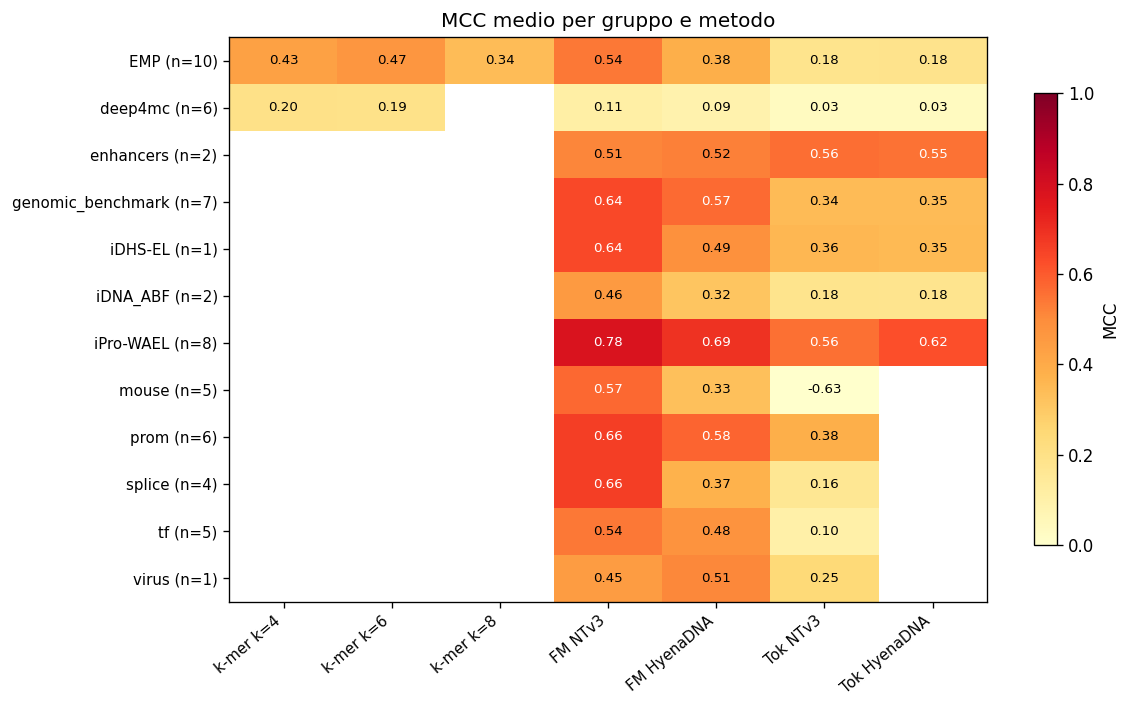

In [21]:
# Heatmap: MCC medio per (gruppo, metodo)
methods_hm = {}
for k in [4,6,8]:
    methods_hm[f'k-mer k={k}'] = f'kmer_k{k}_MCC'
methods_hm[f'FM {FM_NT}'] = 'fm_NTv3_650M_pre_MCC'
methods_hm[f'FM {FM_HY}'] = 'fm_hyenadna-medium-160k-seqlen-hf_MCC'
methods_hm[f'Tok {FM_NT}'] = 'tok_NTv3_650M_pre_MCC'
methods_hm[f'Tok {FM_HY}'] = 'tok_hyenadna-medium-160k-seqlen-hf_MCC'

rows = []
for g in groups:
    gdf = df[df['group'] == g]
    row = {'group': g, 'n': len(gdf)}
    for mname, col in methods_hm.items():
        if col in gdf.columns:
            row[mname] = gdf[col].mean()
    rows.append(row)
summary = pd.DataFrame(rows).set_index('group')
n_col = summary.pop('n')
summary = summary[[c for c in methods_hm.keys() if c in summary.columns]]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(summary.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(summary.columns)))
ax.set_xticklabels(summary.columns, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(summary)))
ax.set_yticklabels([f'{g} (n={int(n_col[g])})' for g in summary.index], fontsize=9)

for i in range(len(summary)):
    for j in range(len(summary.columns)):
        val = summary.iloc[i, j]
        if pd.notna(val):
            color = 'white' if val > 0.55 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

ax.set_title('MCC medio per gruppo e metodo')
plt.colorbar(im, ax=ax, label='MCC', shrink=0.8)
plt.tight_layout()
plt.show()

## 9. Gap FM-kmer vs lunghezza sequenza

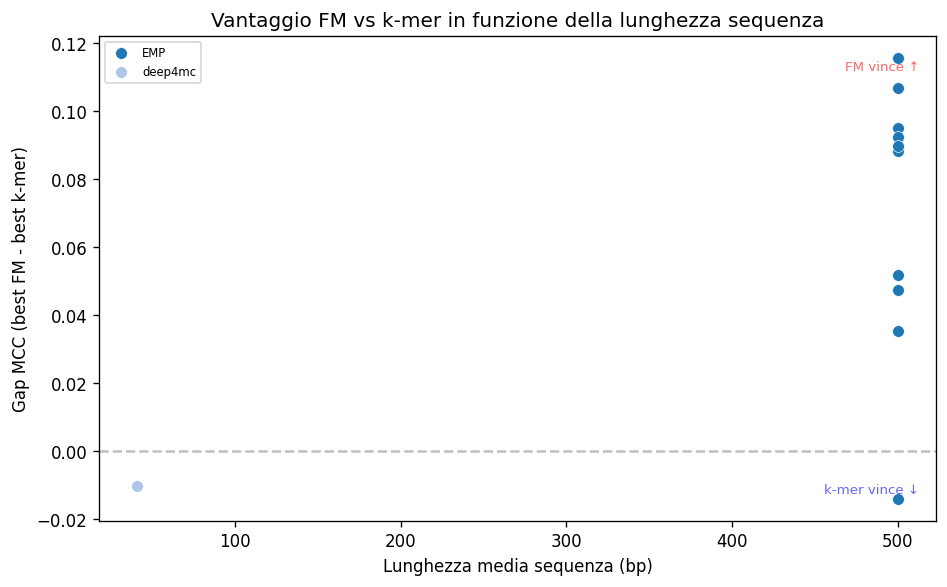

In [22]:
# Gap (FM - kmer) vs seq_len_mean: i FM guadagnano di più sulle sequenze lunghe?
kmer_mcc = [f'kmer_k{k}_MCC' for k in [4,5,6,7,8]]
fm_mcc = ['fm_NTv3_650M_pre_MCC', 'fm_hyenadna-medium-160k-seqlen-hf_MCC']

gap = pd.DataFrame({
    'gap': df[fm_mcc].max(axis=1) - df[kmer_mcc].max(axis=1),
    'seq_len': df['seq_len_mean'],
    'group': df['group']
}).dropna()

fig, ax = plt.subplots(figsize=(8, 5))
for g in groups:
    m = gap['group'] == g
    if m.any():
        ax.scatter(gap.loc[m, 'seq_len'], gap.loc[m, 'gap'],
                   c=[GROUP_COLORS[g]], label=g, s=50, edgecolors='white', lw=0.4, zorder=3)

ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Lunghezza media sequenza (bp)')
ax.set_ylabel('Gap MCC (best FM - best k-mer)')
ax.set_title('Vantaggio FM vs k-mer in funzione della lunghezza sequenza')
ax.legend(fontsize=7, loc='best')

# Annotazione zone
ax.text(0.98, 0.95, 'FM vince ↑', transform=ax.transAxes, ha='right', va='top', fontsize=8, color='red', alpha=0.6)
ax.text(0.98, 0.05, 'k-mer vince ↓', transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='blue', alpha=0.6)
plt.tight_layout()
plt.show()

## 10. Riepilogo: ranking medio per metodo

In [23]:
# Per ogni dataset, calcola il ranking di ciascun metodo (1=migliore)
all_methods = {}
for k in [4,5,6,7,8]:
    all_methods[f'k-mer k={k}'] = f'kmer_k{k}_MCC'
all_methods[f'FM {FM_NT}'] = 'fm_NTv3_650M_pre_MCC'
all_methods[f'FM {FM_HY}'] = 'fm_hyenadna-medium-160k-seqlen-hf_MCC'
all_methods[f'Tok {FM_NT}'] = 'tok_NTv3_650M_pre_MCC'
all_methods[f'Tok {FM_HY}'] = 'tok_hyenadna-medium-160k-seqlen-hf_MCC'

mcc_wide = df[[c for c in all_methods.values() if c in df.columns]].copy()
mcc_wide.columns = [k for k, v in all_methods.items() if v in df.columns]

# Ranking per riga (ascending=False → MCC più alto = rank 1)
ranks = mcc_wide.rank(axis=1, ascending=False)

summary = pd.DataFrame({
    'MCC medio': mcc_wide.mean().round(3),
    'MCC mediano': mcc_wide.median().round(3),
    'Rank medio': ranks.mean().round(2),
    'n dataset': mcc_wide.notna().sum()
}).sort_values('Rank medio')

summary

,MCC medio,MCC mediano,Rank medio,n dataset
FM NTv3,0.562,0.543,1.28,57
k-mer k=6,0.443,0.429,2.18,11
FM HyenaDNA,0.448,0.449,2.77,57
k-mer k=5,0.425,0.386,3.36,11
k-mer k=4,0.411,0.363,4.00,11
Tok NTv3,0.198,0.191,4.16,57
k-mer k=7,0.433,0.392,4.40,10
Tok HyenaDNA,0.304,0.234,4.74,35
k-mer k=8,0.343,0.307,6.70,10
